In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.lines as mlines

In [2]:
from alphagenome_pytorch.plotting.splicing import (
    plot_splice_site_dynamics, plot_splice_site_predictions, plot_usage_density,
    SPLICE_CLASS_NAMES,
    BACKGROUND_CLASS,
    CLASS_LABELS,
    CLASS_COLORS,
    TISSUE_COLORS,
    TISSUE_ORDER,
    SPECIES_ORDER,
    SPECIES,
    SPECIES_SCI,
    CHR_SIZES
)

CLASS_LABELS = {
    0: 'Donor+',
    1: 'Donor-',
    2: 'Acceptor+',
    3: 'Acceptor-',
    4: 'Binary'
}

## Load data

In [3]:
# Collect metrics for plotting
metrics_dict = {}

# Load saved predictions 
base_dir = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai"
models = [
    "human", 
    "mouse",
    "human_mouse", 
    "human_mouse_rat", 
    "human_mouse_rat_rabbit", 
    "human_rat_rabbit_opossum",
    "human_mouse_rat_rabbit_opossum"
]
model_names = ["132kb_encode_intersect_usage_pc_obs_" + model for model in models]

# Shades of blue for different models
MODEL_COLORS = {
    "human": "#b3cbeb",
    "mouse": "#b3cbeb",
    "human_mouse": "#9ecae1",
    "human_mouse_rat": "#6baed6",
    "human_mouse_rat_rabbit": "#4292c6",
    "human_rat_rabbit_opossum": "#2978ad",
    "human_mouse_rat_rabbit_opossum": "#155786"
}

# Shades for different species
SPECIES_COLORS = {
    'human': "#80b1d3",
    'mouse': "#b3de69",
    'rat': "#fdb462",
    'rabbit': "#fb8072",
    'opossum': "#bebada",
    "chicken": "#ffffb3",
    "macaque": "#8dd3c7",
}

# Generate shades from light to dark for each tissue
import matplotlib.colors as mcolors
def make_tissue_shades(base_color, n):
    """From a light tint to the full base color."""
    base = mcolors.to_rgb(base_color)
    return [
        tuple(1 - (1 - c) * (i + 1) / n for c in base)
        for i in range(n)
    ]

n_models = len(models)
TISSUE_MODEL_COLORS = {
    tissue: dict(zip(models, make_tissue_shades(TISSUE_COLORS[tissue], n_models)))
    for tissue in TISSUE_ORDER
}


Load loss data.

In [5]:
loss_dict = {}
for model, model_name in zip(models, model_names):
    log_file = os.path.join(base_dir, model_name, "epoch_log.csv")
    if not os.path.exists(log_file):
        print(f"Log file not found for model {model_name}: {log_file}")
        continue
    df = pd.read_csv(log_file, usecols=['epoch', 'train_loss', 'val_loss'])
    loss_dict[model] = df

# Collect loss data, combine by column names
loss_df = pd.DataFrame()
for model, df in loss_dict.items():
    df = df.copy()
    df['model'] = model
    loss_df = pd.concat([loss_df, df], ignore_index=True)

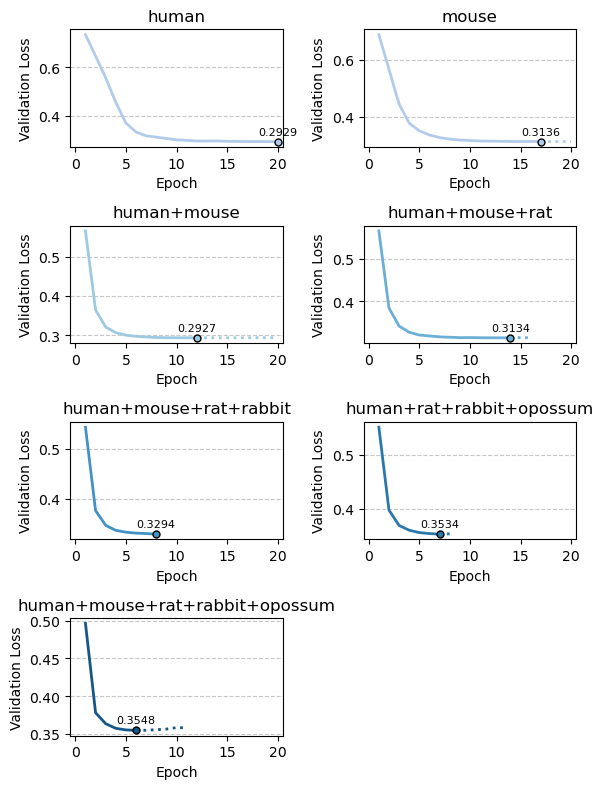

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Only keep models that actually have data
valid_models = [m for m in models if m in loss_dict]
n_models = len(valid_models)

ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2 * nrows), squeeze=False)
axes = axes.flatten()

for ax, model in zip(axes, valid_models):
    df = loss_dict[model]
    color = MODEL_COLORS[model]

    min_epoch_idx = df['val_loss'].idxmin()
    best_epoch = df.loc[min_epoch_idx, 'epoch']

    # Split into solid (up to and including best epoch) and dotted (after) segments
    solid = df[df['epoch'] <= best_epoch]
    dotted = df[df['epoch'] >= best_epoch]  # include best_epoch so lines connect

    ax.plot(solid['epoch'], solid['val_loss'], color=color, linewidth=2,
            linestyle='-', zorder=3, label=model)
    if len(dotted) > 1:
        ax.plot(dotted['epoch'], dotted['val_loss'], color=color, linewidth=2,
                linestyle=':', zorder=3)

    # indicate the epoch with the lowest validation loss
    ax.scatter(df.loc[min_epoch_idx, 'epoch'], df.loc[min_epoch_idx, 'val_loss'],
               color=color, s=25, edgecolor='black', zorder=5)

    # annotate the point with the epoch number
    ax.annotate(f"{df.loc[min_epoch_idx, 'val_loss']:.4f}",
                (df.loc[min_epoch_idx, 'epoch'], df.loc[min_epoch_idx, 'val_loss']),
                textcoords="offset points", xytext=(0, 5), ha='center', fontsize=8)

    # Integer axis labels
    ax.set_xticks(np.arange(0, loss_df['epoch'].max() + 1, step=5))
    ax.set_xlim(-0.5, loss_df['epoch'].max() + 0.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Loss')
    ax.set_title(model.replace('_', '+'))
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Hide any unused subplot axes
for ax in axes[n_models:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Load predictions data.

In [6]:
# Predictions subset directory
preds_dir = "preds_intersect_protein_coding"

# Load data
for model, model_name in zip(models, model_names):
    preds_path = f"{base_dir}/{model_name}/{preds_dir}"
    for pred_sps in ["human", "mouse", "rat", "rabbit", "opossum"]:
        # Construct prediction directory path
        pred_dir = f"{base_dir}/{model_name}/{preds_dir}/{pred_sps}"
        # Load predictions
        metrics_fn = f"{pred_dir}/metrics.json"
        if os.path.exists(metrics_fn):
            #print(f"  Loading {metrics_fn}")
            with open(metrics_fn, "r") as f:
                metrics = json.load(f)
            # Collect metrics for plotting (only if file exists)
            metrics_dict[(model, preds_path, pred_sps)] = metrics
        else:
            print(f"  File not found: {metrics_fn}")

  File not found: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_encode_intersect_usage_pc_obs_mouse/preds_intersect_protein_coding/human/metrics.json
  File not found: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_encode_intersect_usage_pc_obs_mouse/preds_intersect_protein_coding/mouse/metrics.json
  File not found: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_encode_intersect_usage_pc_obs_mouse/preds_intersect_protein_coding/rat/metrics.json
  File not found: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_encode_intersect_usage_pc_obs_mouse/preds_intersect_protein_coding/rabbit/metrics.json
  File not found: /home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/132kb_encode_intersect_usage_pc_obs_mouse/preds_intersect_protein_coding/opossum/metrics.json


## Splice site classification (AUPRC per class)

In [7]:
# Extract classification metrics (AUPRC per class)
classification_data = []

# Mapping from class names to indices
class_name_to_idx = {
    'Donor+': 0,
    'Acceptor+': 1,
    'Donor-': 2,
    'Acceptor-': 3
}

for (model, preds_path, pred_sps), metrics in metrics_dict.items():
    if pred_sps in metrics:
        species_metrics = metrics[pred_sps]
        
        # Per-class AUPRC (stored in "per_class_auprc" dict)
        if 'per_class_auprc' in species_metrics:
            for class_name, auprc_value in species_metrics['per_class_auprc'].items():
                class_idx = class_name_to_idx.get(class_name)
                if class_idx is not None:
                    classification_data.append({
                        'model': model,
                        'pred_species': pred_sps,
                        'class_idx': class_idx,
                        'class_label': CLASS_LABELS[class_idx],
                        'auprc': auprc_value
                    })
        
        # Binary AUPRC (any splice site vs background)
        if 'binary_auprc' in species_metrics:
            classification_data.append({
                'model': model,
                'pred_species': pred_sps,
                'class_idx': 4,
                'class_label': 'binary',
                'auprc': species_metrics['binary_auprc']
            })

df_classification = pd.DataFrame(classification_data)
print(f"Extracted {len(df_classification)} classification metrics")
df_classification

Extracted 125 classification metrics


,model,pred_species,class_idx,class_label,auprc
0,human,human,0,Donor+,0.886453
1,human,human,1,Donor-,0.876363
2,human,human,2,Acceptor+,0.895303
3,human,human,3,Acceptor-,0.890913
4,human,human,4,binary,0.887340
...,...,...,...,...,...
120,human_mouse_rat_rabbit_opossum,opossum,0,Donor+,0.887175
121,human_mouse_rat_rabbit_opossum,opossum,1,Donor-,0.887387
122,human_mouse_rat_rabbit_opossum,opossum,2,Acceptor+,0.906299
123,human_mouse_rat_rabbit_opossum,opossum,3,Acceptor-,0.908348


Plot grouped barplot of classification AUPRC.

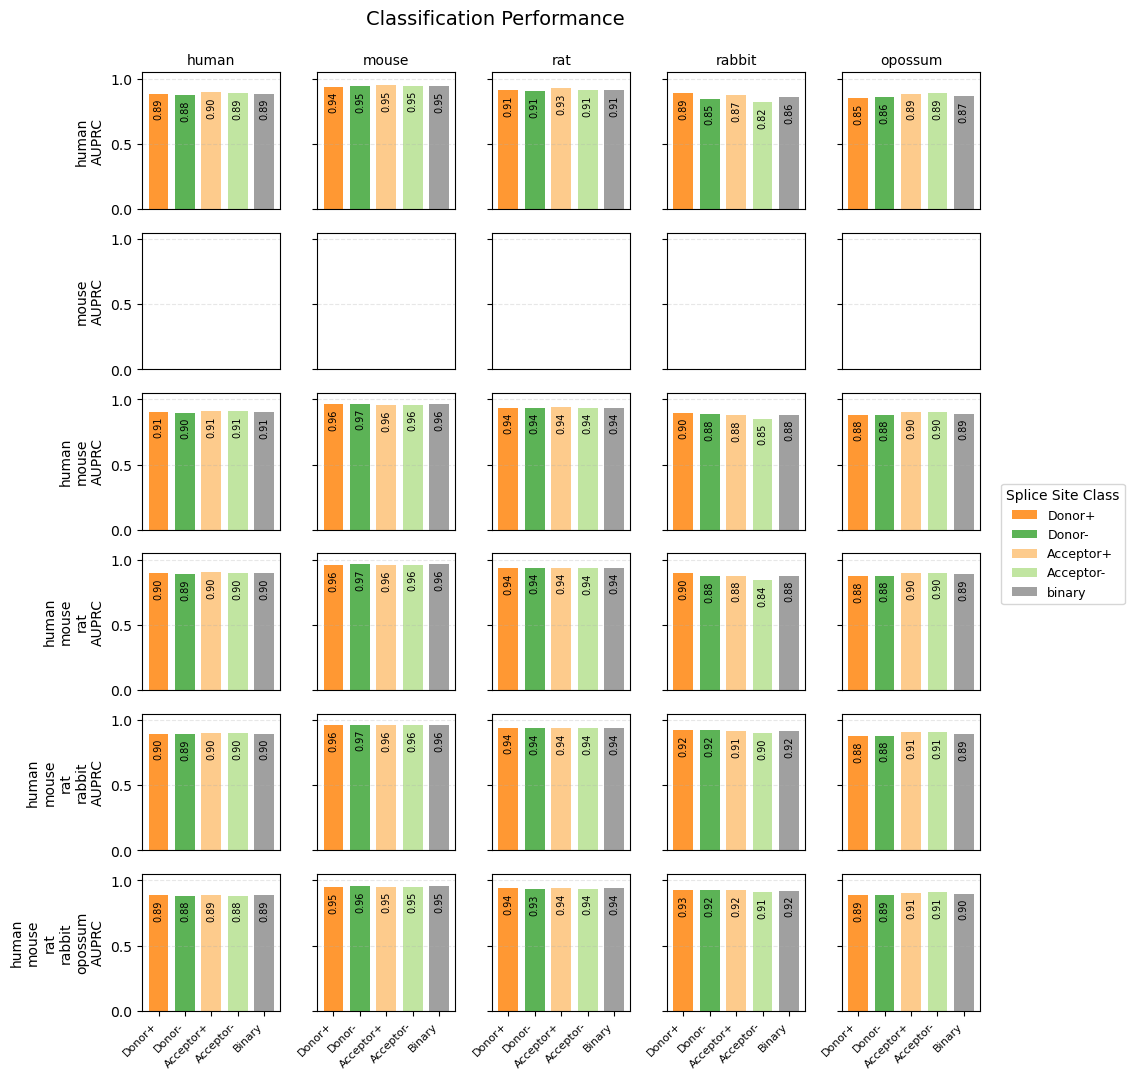

In [8]:
# Grouped barplot: Classification AUPRC by class, organized in grid
# Rows = models, Columns = evaluation species
import matplotlib.pyplot as plt
import numpy as np

# Get unique models and prediction species
pred_species_list = sorted(df_classification['pred_species'].unique())
pred_species_list = [s for s in SPECIES_ORDER if s in pred_species_list]
classes = sorted(df_classification['class_idx'].unique())

n_models = len(models)
n_species = len(pred_species_list)
n_classes = len(classes)

# Create subplot grid: rows = models, cols = species
fig, axes = plt.subplots(n_models, n_species, figsize=(n_species * 2, n_models * 1.8),
                         squeeze=False, sharex=False, sharey=True)

bar_width = 0.25
x = np.arange(n_classes)

# Plot each model × species combination
for model_idx, model in enumerate(models):
    for species_idx, pred_sps in enumerate(pred_species_list):
        ax = axes[model_idx, species_idx]

        # Filter data for this model and species
        subset = df_classification[
            (df_classification['model'] == model) &
            (df_classification['pred_species'] == pred_sps)
        ]

        if len(subset) > 0:
            # Plot bars for each class
            for i, class_idx in enumerate(classes):
                class_data = subset[subset['class_idx'] == class_idx]

                if len(class_data) > 0:
                    auprc_value = class_data['auprc'].values[0]

                    # Use class colors
                    color = CLASS_COLORS.get(class_idx, '#888888')
                    label = CLASS_LABELS.get(class_idx, f'class_{class_idx}')
                    if class_idx == 4:  # Binary
                        label = 'binary'
                        color = '#888888'

                    bar = ax.bar(i, auprc_value, bar_width * 3, color=color, alpha=0.8,
                          label=label if model_idx == 0 and species_idx == 0 else "")

                    # Add value on top of bar
                    ax.text(i, auprc_value - 0.2, f'{auprc_value:.2f}',
                            ha='center', va='bottom', fontsize=7, rotation=90)

        # Customize subplot
        ax.set_ylim(0, 1.05)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        # Set title for top row (species names)
        if model_idx == 0:
            ax.set_title(pred_sps, fontsize=10)

        # Set ylabel for leftmost column (model names)
        if species_idx == 0:
            # Split model name for better display
            model_display_name = model.replace('_', '+')
            model_display_name = '\n'.join(model_display_name.split('+'))
            ax.set_ylabel(f'{model_display_name}\nAUPRC', fontsize=10)

        # Only show x-ticks on bottom row
        if model_idx == n_models - 1:
            ax.set_xticks(range(n_classes))
            ax.set_xticklabels([CLASS_LABELS.get(c, 'binary') for c in classes],
                              rotation=45, ha='right', fontsize=8)
        else:
            ax.set_xticks([])

# Add overall title
fig.suptitle('Classification Performance', fontsize=14, y=0.995)

# Create legend (only once, outside subplots)
handles = []
labels = []
for class_idx in classes:
    color = CLASS_COLORS.get(class_idx, '#888888')
    label = CLASS_LABELS.get(class_idx, f'class_{class_idx}')
    if class_idx == 4:
        label = 'binary'
        color = '#888888'
    handles.append(plt.Rectangle((0,0),1,1, fc=color, alpha=0.8))
    labels.append(label)

fig.legend(handles, labels, title='Splice Site Class',
          loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)

plt.tight_layout()
plt.show()


Plot all models per class.

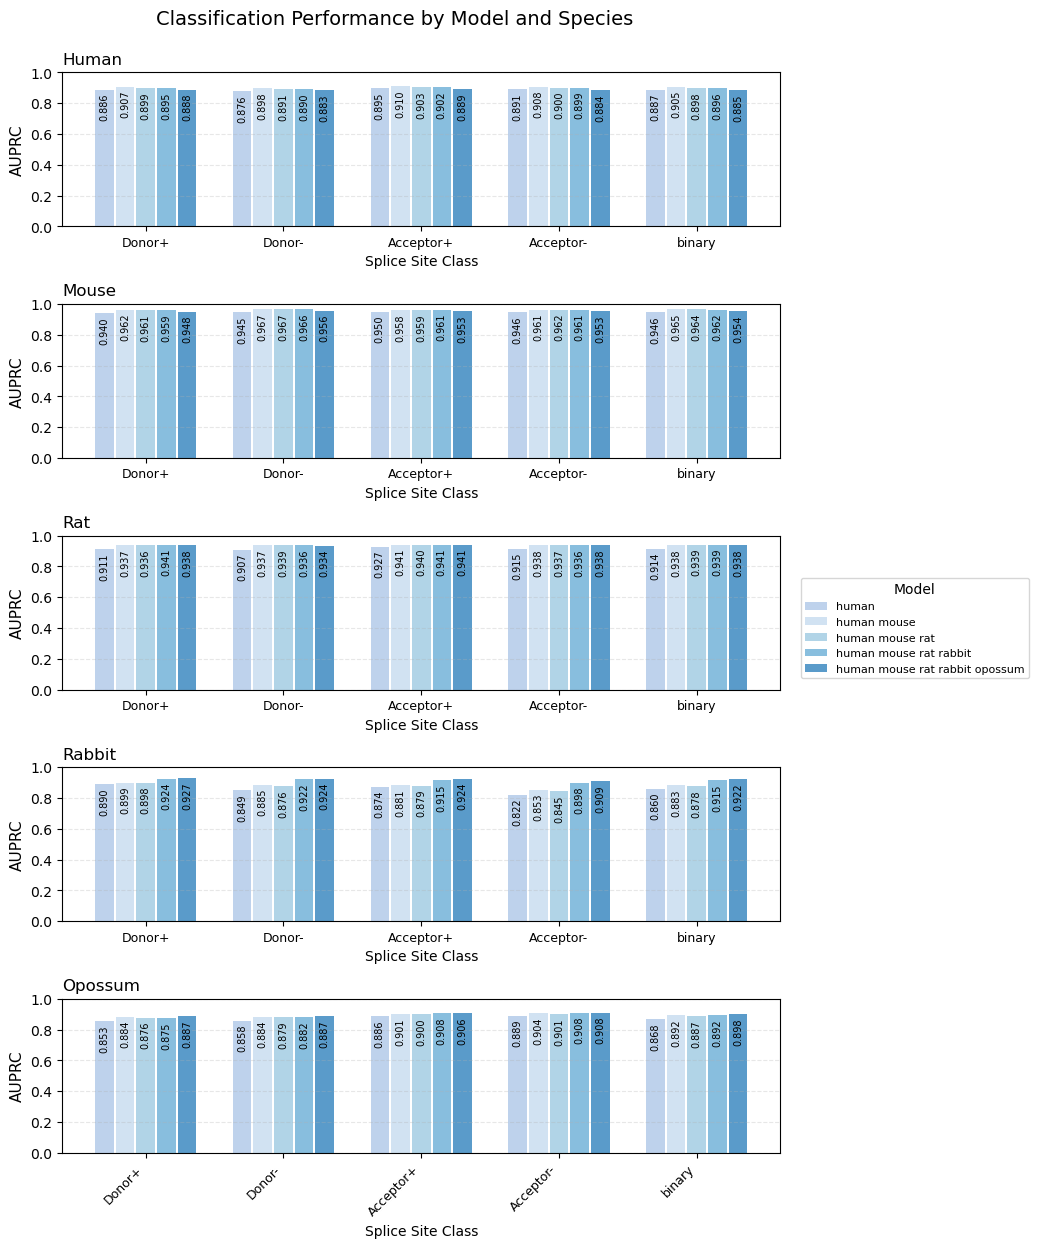

In [9]:
# Grouped barplot: classes grouped by model, one plot per species
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Subset those models for which we have data
models_classification = [model for model in models if model in df_classification['model'].unique()]

# Get unique prediction species and classes
pred_species_list = [s for s in SPECIES_ORDER if s in df_classification['pred_species'].unique()]
classes = sorted(df_classification['class_idx'].unique())
n_classes = len(classes)
n_species = len(pred_species_list)

# Create subplots: one row per prediction species
fig, axes = plt.subplots(n_species, 1, figsize=(8, n_species * 2.5), squeeze=False)
axes = axes.flatten()

for species_idx, pred_sps in enumerate(pred_species_list):
    ax = axes[species_idx]
    
    # Filter data for this species
    species_data = df_classification[df_classification['pred_species'] == pred_sps]
    
    # Get models present for this species, in the defined order
    models_present = [m for m in models_classification if m in species_data['model'].unique()]
    n_models = len(models_present)
    
    # Spacing parameters
    bar_width = 0.15
    class_spacing = 1.0
    
    for model_idx, model in enumerate(models_present):
        model_data = species_data[species_data['model'] == model]
        color = MODEL_COLORS[model]
        
        for class_idx, cls in enumerate(classes):
            class_data = model_data[model_data['class_idx'] == cls]
            
            if len(class_data) > 0:
                auprc_value = class_data['auprc'].values[0]
                
                # Position: class group + model offset within group
                x_pos = class_idx * class_spacing + model_idx * bar_width
                
                ax.bar(x_pos, auprc_value, bar_width * 0.9, 
                       color=color, alpha=0.8,
                       label=model.replace('_', ' ') if class_idx == 0 else "")
                
                # Add value on top
                if auprc_value > 0.5:  # Only show if high enough
                    ax.text(x_pos, auprc_value - 0.2, f'{auprc_value:.3f}',
                            ha='center', va='bottom', fontsize=7, rotation=90)
    
    # Customize subplot
    ax.set_ylim(0, 1)
    ax.set_ylabel('AUPRC', fontsize=11)
    ax.set_title(f'{pred_sps.capitalize()}', fontsize=12, loc='left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Set x-ticks at the center of each class group
    tick_positions = [class_idx * class_spacing + (n_models * bar_width) / 2 - bar_width/2 
                     for class_idx in range(n_classes)]
    ax.set_xticks(tick_positions)
    
    # Create class labels
    class_labels = []
    for cls in classes:
        label = CLASS_LABELS.get(cls, f'class_{cls}')
        if cls == 4:
            label = 'binary'
        class_labels.append(label)
    
    if species_idx == n_species - 1:
        ax.set_xticklabels(class_labels, rotation=45, ha='right', fontsize=9)
    else:
        ax.set_xticklabels(class_labels, fontsize=9)
    ax.set_xlabel('Splice Site Class', fontsize=10)

fig.suptitle('Classification Performance by Model and Species', fontsize=14, y=0.995)

# Create model legend with colors
legend_handles = []
for model in models_classification:
    color = MODEL_COLORS[model]
    legend_handles.append(Patch(facecolor=color, alpha=0.8, label=model.replace('_', ' ')))

fig.legend(handles=legend_handles, title='Model',
          loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)

plt.tight_layout()
plt.show()

Dfference relative to the human model baseline.

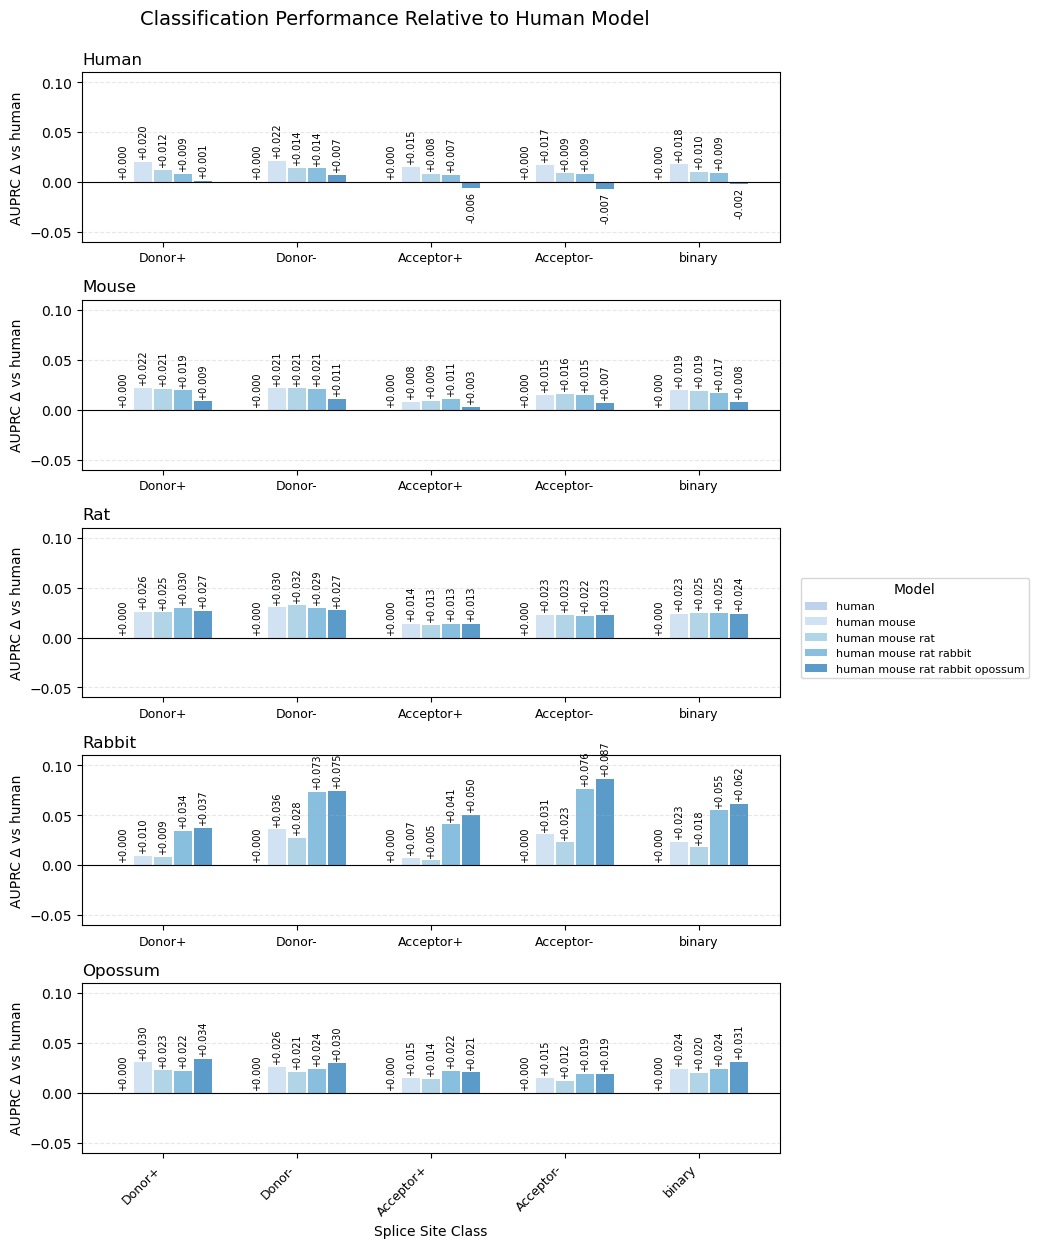

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

BASELINE_MODEL = 'human'

# Subset those models for which we have data
models_classification = [model for model in models if model in df_classification['model'].unique()]

# Get unique prediction species and classes
pred_species_list = [s for s in SPECIES_ORDER if s in df_classification['pred_species'].unique()]
classes = sorted(df_classification['class_idx'].unique())
n_classes = len(classes)
n_species = len(pred_species_list)

# Create subplots: one row per prediction species
fig, axes = plt.subplots(n_species, 1, figsize=(8, n_species * 2.5), squeeze=False)
axes = axes.flatten()

for species_idx, pred_sps in enumerate(pred_species_list):
    ax = axes[species_idx]

    # Filter data for this species
    species_data = df_classification[df_classification['pred_species'] == pred_sps]

    # Get models present for this species, in the defined order
    models_present = [m for m in models_classification if m in species_data['model'].unique()]
    n_models = len(models_present)

    # Get baseline AUPRC per class for this species
    baseline_data = species_data[species_data['model'] == BASELINE_MODEL]
    baseline_by_class = {
        cls: baseline_data[baseline_data['class_idx'] == cls]['auprc'].values[0]
        for cls in classes
        if len(baseline_data[baseline_data['class_idx'] == cls]) > 0
    }

    # Spacing parameters
    bar_width = 0.15
    class_spacing = 1.0

    for model_idx, model in enumerate(models_present):
        model_data = species_data[species_data['model'] == model]
        color = MODEL_COLORS[model]

        for class_idx, cls in enumerate(classes):
            class_data = model_data[model_data['class_idx'] == cls]
            if len(class_data) > 0 and cls in baseline_by_class:
                auprc_value = class_data['auprc'].values[0]
                diff_value = auprc_value - baseline_by_class[cls]

                # Position: class group + model offset within group
                x_pos = class_idx * class_spacing + model_idx * bar_width

                ax.bar(x_pos, diff_value, bar_width * 0.9,
                       color=color, alpha=0.8,
                       label=model.replace('_', ' ') if class_idx == 0 else "")

                # Add value label above/below bar depending on sign
                va = 'bottom' if diff_value >= 0 else 'top'
                offset = 0.0025 if diff_value >= 0 else -0.0025
                ax.text(x_pos, diff_value + offset, f'{diff_value:+.3f}',
                        ha='center', va=va, fontsize=7, rotation=90)

    # Customize subplot
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel(f'AUPRC Δ vs {BASELINE_MODEL}', fontsize=10)
    ax.set_title(f'{pred_sps.capitalize()}', fontsize=12, loc='left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Set x-ticks at the center of each class group
    tick_positions = [class_idx * class_spacing + (n_models * bar_width) / 2 - bar_width/2
                       for class_idx in range(n_classes)]
    ax.set_xticks(tick_positions)

    # Create class labels
    class_labels = []
    for cls in classes:
        label = CLASS_LABELS.get(cls, f'class_{cls}')
        if cls == 4:
            label = 'binary'
        class_labels.append(label)

    if species_idx == n_species - 1:
        ax.set_xticklabels(class_labels, rotation=45, ha='right', fontsize=9)
        ax.set_xlabel('Splice Site Class', fontsize=10)
    else:
        ax.set_xticklabels(class_labels, fontsize=9)

    ax.set_ylim(-0.06, 0.11)

fig.suptitle(f'Classification Performance Relative to {BASELINE_MODEL.capitalize()} Model', fontsize=14, y=0.995)

# Create model legend with colors
legend_handles = []
for model in models_classification:
    color = MODEL_COLORS[model]
    legend_handles.append(Patch(facecolor=color, alpha=0.8, label=model.replace('_', ' ')))
fig.legend(handles=legend_handles, title='Model',
           loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)

plt.tight_layout()
plt.show()

## Splice usage metrics (per-condition correlations)

In [11]:
# Extract per-condition usage correlations from saved predictions
# We'll compute correlations from the usage .npz files and map to tissues via metadata

from scipy.stats import pearsonr
from pathlib import Path

def get_pooled_r(metrics_entry, pred_sps, usage_head_species):
    """Look up the pooled Pearson r for a given species/head from metrics dict entry.
    usage_by_head keys may be either the bare species name ("human") or
    prefixed with "from_" ("from_human"), so we try both.
    """
    species_m = metrics_entry.get(pred_sps, {})
    by_head = species_m.get('usage_by_head', {})
    if by_head:
        # Try bare name first, then "from_<name>"
        for key in (usage_head_species, f"from_{usage_head_species}"):
            val = by_head.get(key, {}).get('usage_pearson_r')
            if val is not None:
                return val
        return None
    return species_m.get('usage_pearson_r', None)

usage_data_list = []

verbose = True  # Set to True to print debug info

for (model, preds_path, pred_sps), metrics in metrics_dict.items():
    pred_dir = Path(f"{preds_path}/{pred_sps}")
    
    # Load usage metadata to map conditions to tissues
    species_map = {'human': 'Homo_sapiens', 'mouse': 'Mus_musculus', 'rat': 'Rattus_norvegicus', 'rabbit': 'Oryctolagus_cuniculus', 'opossum': 'Monodelphis_domestica'}
    metadata_path = Path(f"{base_dir}/data/{species_map[pred_sps]}/usage.json")
    
    if not metadata_path.exists():
        print(f"Metadata not found: {metadata_path}")
        continue
    
    with open(metadata_path) as f:
        usage_metadata = json.load(f)
    condition_labels = usage_metadata.get("condition_labels", {})
    idx_to_name = {int(v): k for k, v in condition_labels.items()}
    
    # Build usage_files list fully before iterating
    usage_files = []
    for model_sps in model.split('_'):
        if model_sps != pred_sps:
            candidate = (f"usage_{pred_sps}_from_{model_sps}.npz", model_sps)
            if candidate not in usage_files:
                usage_files.append(candidate)
        else:
            candidate = (f"usage_{pred_sps}.npz", model_sps)
            if candidate not in usage_files:
                usage_files.append(candidate)

    for usage_file, usage_head_species in usage_files:
        usage_path = pred_dir / usage_file
        
        if not usage_path.exists():
            print(f"Usage file not found: {usage_path}")
            continue

        if verbose:
            print(f"model={model}, pred_species={pred_sps}, usage_head_species={usage_head_species}")

        pooled_r = get_pooled_r(metrics, pred_sps, usage_head_species)
        usage_data = np.load(usage_path)
        
        # Compute per-condition correlations using summary statistics
        stats_cond_ids = usage_data['stats_cond_ids']
        stats_n = usage_data['stats_n']
        stats_sum_pred = usage_data['stats_sum_pred']
        stats_sum_true = usage_data['stats_sum_true']
        stats_sum_pred2 = usage_data['stats_sum_pred2']
        stats_sum_true2 = usage_data['stats_sum_true2']
        stats_sum_prod = usage_data['stats_sum_prod']
        
        for i, cond_idx in enumerate(stats_cond_ids):
            n = stats_n[i]
            if n <= 1:
                continue
            
            # Pearson r from summary statistics
            numerator = n * stats_sum_prod[i] - stats_sum_pred[i] * stats_sum_true[i]
            denom_pred = n * stats_sum_pred2[i] - stats_sum_pred[i] ** 2
            denom_true = n * stats_sum_true2[i] - stats_sum_true[i] ** 2
            
            if denom_pred > 0 and denom_true > 0:
                r = numerator / np.sqrt(denom_pred * denom_true)
            else:
                continue
            
            # Get condition name and extract tissue
            cond_name = idx_to_name.get(int(cond_idx), f"unknown_{cond_idx}")
            tissue = cond_name.rsplit('_', 1)[0] if '_' in cond_name else cond_name
            
            try:
                timepoint = int(cond_name.rsplit('_', 1)[1]) if '_' in cond_name else None
            except:
                timepoint = None

            usage_data_list.append({
                'model': model,
                'model_species': usage_head_species,
                'pred_species': pred_sps,
                'tissue': tissue,
                'condition_idx': int(cond_idx),
                'condition_name': cond_name,
                'timepoint': timepoint,
                'correlation': float(r),
                'pooled_r': float(pooled_r) if pooled_r is not None else float('nan'),
                'n': int(n)
            })

df_usage_ = pd.DataFrame(usage_data_list)
print(f"Extracted {len(df_usage_)} per-condition usage correlations")
df_usage_

model=human, pred_species=human, usage_head_species=human
model=human, pred_species=mouse, usage_head_species=human
model=human, pred_species=rat, usage_head_species=human
model=human, pred_species=rabbit, usage_head_species=human
model=human, pred_species=opossum, usage_head_species=human
model=human_mouse, pred_species=human, usage_head_species=human
model=human_mouse, pred_species=human, usage_head_species=mouse
model=human_mouse, pred_species=mouse, usage_head_species=human
model=human_mouse, pred_species=mouse, usage_head_species=mouse
model=human_mouse, pred_species=rat, usage_head_species=human
model=human_mouse, pred_species=rat, usage_head_species=mouse
model=human_mouse, pred_species=rabbit, usage_head_species=human
model=human_mouse, pred_species=rabbit, usage_head_species=mouse
model=human_mouse, pred_species=opossum, usage_head_species=human
model=human_mouse, pred_species=opossum, usage_head_species=mouse
model=human_mouse_rat, pred_species=human, usage_head_species=human

,model,model_species,pred_species,tissue,condition_idx,condition_name,timepoint,correlation,pooled_r,n
0,human,human,human,Brain,0,Brain_1,1,0.856703,0.843450,16673
1,human,human,human,Brain,1,Brain_10,10,0.867471,0.843450,15061
2,human,human,human,Brain,2,Brain_11,11,0.862551,0.843450,13192
3,human,human,human,Brain,3,Brain_12,12,0.819114,0.843450,14885
4,human,human,human,Brain,4,Brain_13,13,0.848172,0.843450,14926
...,...,...,...,...,...,...,...,...,...,...
3860,human_mouse_rat_rabbit_opossum,opossum,opossum,Testis,81,Testis_9,9,0.640669,0.716699,10453
3861,human_mouse_rat_rabbit_opossum,opossum,opossum,Kidney,43,Kidney_14,14,0.778463,0.716699,7519
3862,human_mouse_rat_rabbit_opossum,opossum,opossum,Testis,73,Testis_12,12,0.629976,0.716699,9905
3863,human_mouse_rat_rabbit_opossum,opossum,opossum,Testis,74,Testis_13,13,0.554827,0.716699,11226


Load usage data for all species and conditions (this takes some time).

In [12]:
%%time

data_json_fn = f"{base_dir}/data/data_config.json"
with open(data_json_fn, 'r') as f:
    data_config = json.load(f)

species_list = list(data_config.keys())

usage_dfs = {}
for sps in species_list:
    parquet_path = os.path.expanduser(data_config[sps]["usage_parquet"])
    if not os.path.exists(parquet_path):
        print(f"Not found: {parquet_path}")
        continue
    df = pd.read_parquet(parquet_path)
    usage_dfs[sps] = df
    print(f"{sps}: {len(df):,} rows, columns: {list(df.columns)}")

human: 95,643,315 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
mouse: 95,763,380 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
rat: 120,197,320 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
rabbit: 63,199,928 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
opossum: 58,209,286 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
macaque: 4,438,132 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
chicken: 52,871,521 rows, columns: ['Chromosome', 'Position', 'SSE', 'Alpha', 'Beta', 'Label', 'Condition']
CPU times: user 52.4 s, sys: 14.5 s, total: 1min 6s
Wall time: 12min 38s


Count `n_sites` per condition and species.

In [ ]:
# Build a tidy DataFrame: species × condition → n_sites
# Condition labels come from data_config; usage parquet has one row per site×condition

records = []
for sps, df in usage_dfs.items():
    cond_labels = data_config[sps]["condition_labels"]  # name → index
    idx_to_name = {v: k for k, v in cond_labels.items()}
    known_indices = set(idx_to_name.keys())

    # Identify the condition column (may be named 'condition', 'condition_idx', etc.)
    cond_col = next((c for c in df.columns if "cond" in c.lower()), None)
    if cond_col is None:
        print(f"{sps}: no condition column found in {list(df.columns)}")
        continue

    counts = df[df[cond_col].isin(known_indices)].groupby(cond_col).size().reset_index(name="n_sites")
    for _, row in counts.iterrows():
        cond_idx = int(row[cond_col])
        records.append({
            "pred_species": sps,
            "condition_idx": cond_idx,
            "n_sites": int(row["n_sites"]),
        })

df_sites = pd.DataFrame(records)
print(f"Total rows: {len(df_sites)}")
df_sites.head(10)

# Make sure columns to merge in df_sites are the same type as in df_usage_
key_cols = ["pred_species", "condition_idx"]
for col in key_cols:
    if col in df_sites.columns and col in df_usage_.columns:
        df_sites[col] = df_sites[col].astype(df_usage_[col].dtype)

# Merge usage correlations with site counts
df_usage = df_usage_.merge(df_sites, on=key_cols, how="left")
df_usage['n_sites'] = df_usage['n_sites'].fillna(0).astype(int)
print(f"{len(df_usage)} usage records")
df_usage

Total rows: 483
4325 usage records


,model,model_species,pred_species,tissue,condition_idx,condition_name,timepoint,correlation,pooled_r,n,n_sites
0,human,human,human,Brain,0,Brain_1,1,0.856703,0.843450,16673,1576269
1,human,human,human,Brain,1,Brain_10,10,0.867471,0.843450,15061,1217179
2,human,human,human,Brain,2,Brain_11,11,0.862551,0.843450,13192,437905
3,human,human,human,Brain,3,Brain_12,12,0.819114,0.843450,14885,1864284
4,human,human,human,Brain,4,Brain_13,13,0.848172,0.843450,14926,2128843
...,...,...,...,...,...,...,...,...,...,...,...
4320,human_mouse_rat_rabbit_opossum,opossum,opossum,Testis,81,Testis_9,9,0.640669,0.716699,10453,468649
4321,human_mouse_rat_rabbit_opossum,opossum,opossum,Kidney,43,Kidney_14,14,0.778463,0.716699,7519,119555
4322,human_mouse_rat_rabbit_opossum,opossum,opossum,Testis,73,Testis_12,12,0.629976,0.716699,9905,943577
4323,human_mouse_rat_rabbit_opossum,opossum,opossum,Testis,74,Testis_13,13,0.554827,0.716699,11226,586374


Plot boxplot of usage correlation by condition, groupped by condition.

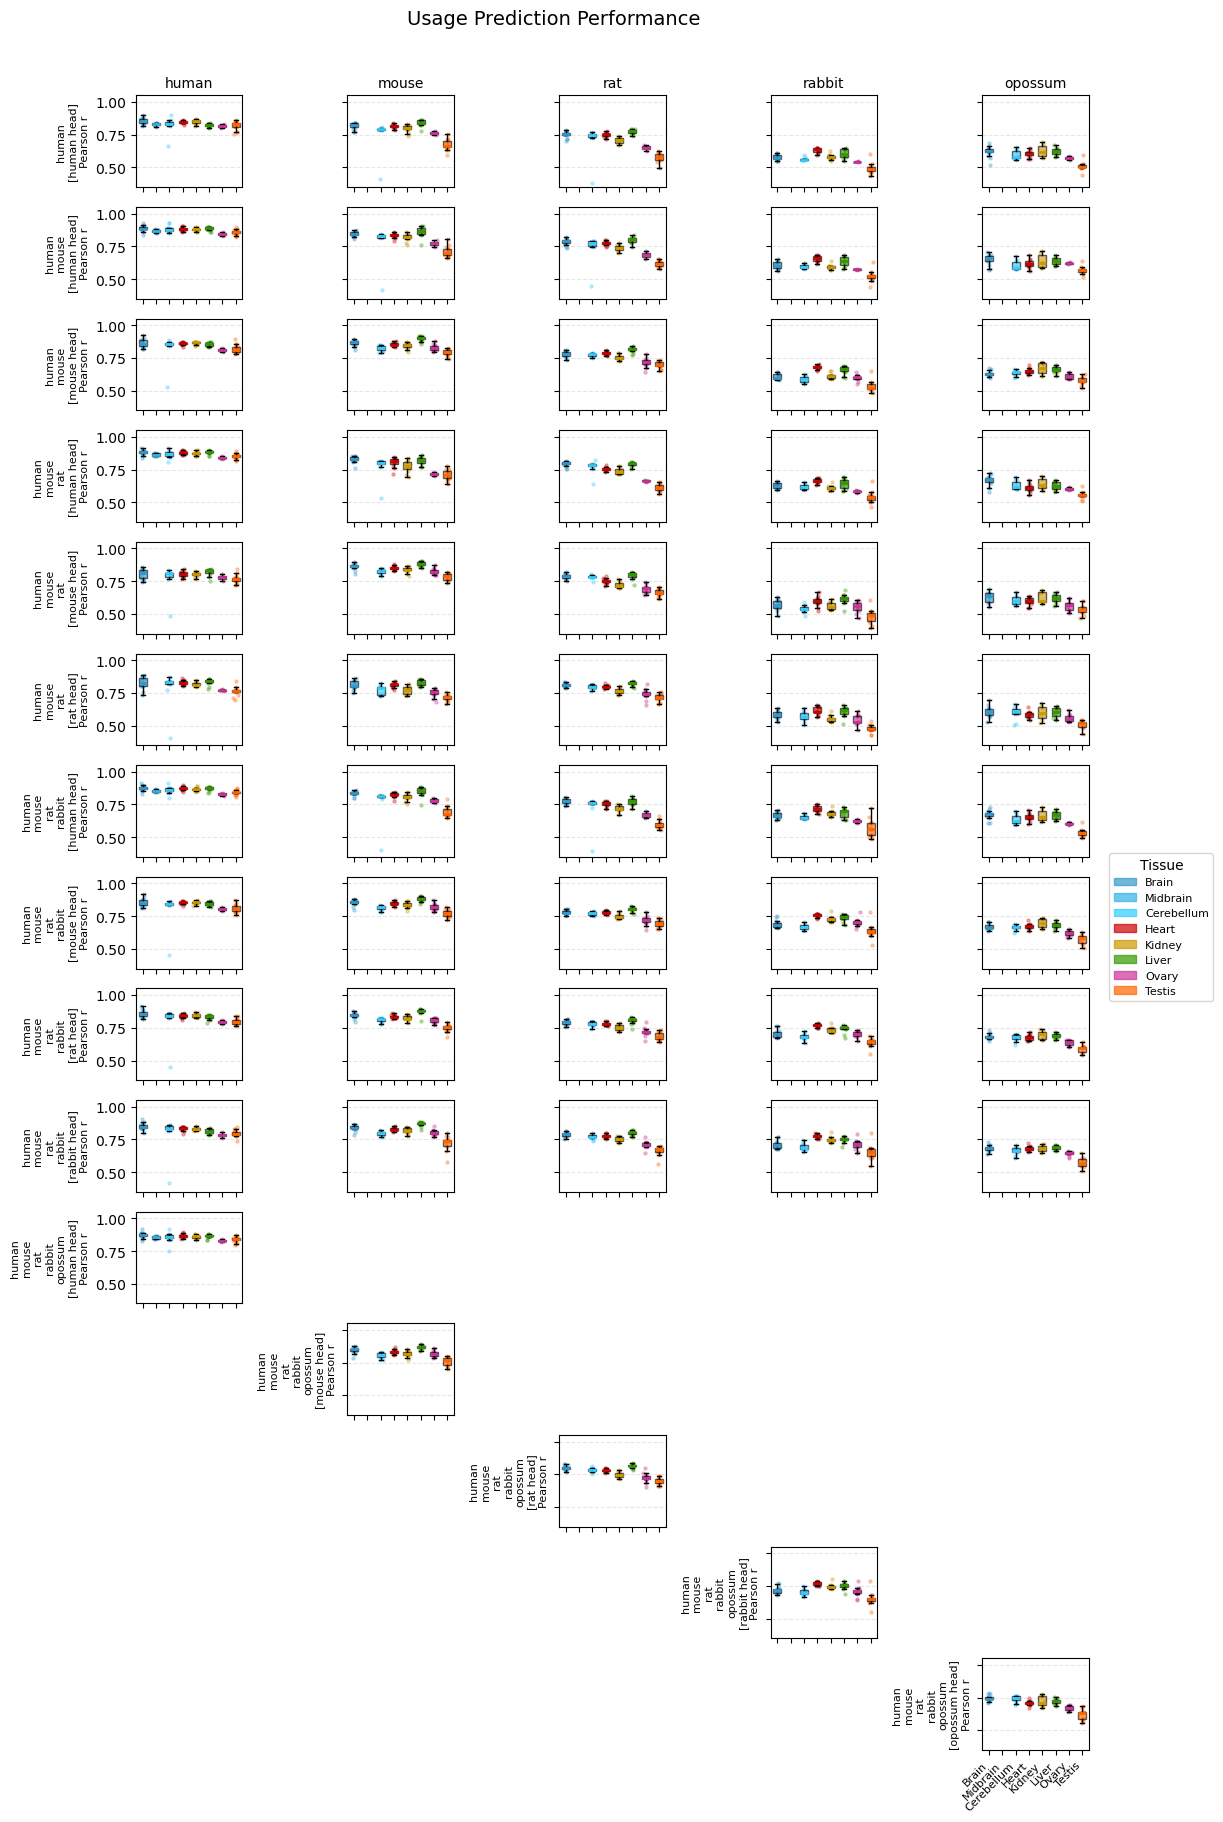

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

pred_species_list = df_usage['pred_species'].unique()
pred_species_list = [s for s in SPECIES_ORDER if s in pred_species_list]
tissues = [t for t in TISSUE_ORDER if t in df_usage['tissue'].unique()]

# Build ordered list of (model, model_species) pairs
model_head_pairs = []
for model in sorted(df_usage['model'].unique()):
    model_species = model.split('_')
    for sps in SPECIES_ORDER:
        if sps in model_species:
            if ((df_usage['model'] == model) & (df_usage['model_species'] == sps)).any():
                model_head_pairs.append((model, sps))

n_rows = len(model_head_pairs)
n_species = len(pred_species_list)

fig, axes = plt.subplots(n_rows, n_species,
                         figsize=(n_species * 2.2, n_rows * 1.2),
                         squeeze=False, sharex=True, sharey=True)


for row_idx, (model, head_sps) in enumerate(model_head_pairs):
    first_visible_in_row = None  # track first non-empty axis in row
    
    for species_idx, pred_sps in enumerate(pred_species_list):
        ax = axes[row_idx, species_idx]
        subset = df_usage[
            (df_usage['model'] == model) &
            (df_usage['pred_species'] == pred_sps) &
            (df_usage['model_species'] == head_sps)
        ]
        if subset.empty:
            ax.axis('off')
            continue

        if first_visible_in_row is None:
            first_visible_in_row = ax
        box_data = [subset[subset['tissue'] == t]['correlation'].values for t in tissues]
        bp = ax.boxplot(
            [bd if len(bd) > 0 else [np.nan] for bd in box_data],
            positions=range(1, len(tissues) + 1),
            patch_artist=True,
            showfliers=False,
            widths=0.6
        )
        for patch, t in zip(bp['boxes'], tissues):
            patch.set_facecolor(TISSUE_COLORS.get(t, '#888888'))
            patch.set_alpha(0.6)
        for median, t in zip(bp['medians'], tissues):
            median.set_color(TISSUE_COLORS.get(t, '#888888'))
            median.set_linewidth(2)
        for pos, bd, t in zip(range(1, len(tissues) + 1), box_data, tissues):
            if len(bd) > 0:
                x_jitter = np.random.normal(pos, 0.07, size=len(bd))
                ax.scatter(x_jitter, bd, alpha=0.3, s=5,
                           color=TISSUE_COLORS.get(t, '#888888'))

        ax.set_ylim(0.35, 1.05)
        ax.set_xlim(0.5, len(tissues) + 0.5)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        if row_idx == 0:
            ax.set_title(pred_sps, fontsize=10)
        if species_idx == 0:
            model_display_name = model.replace('_', '+')
            model_display_name = '\n'.join(model_display_name.split('+'))
            ax.set_ylabel(f'{model_display_name}\n[{head_sps} head]\nPearson r', fontsize=8)

        ax.set_xticks(range(1, len(tissues) + 1))
        if row_idx == n_rows - 1:
            ax.set_xticklabels([t[:10] for t in tissues], rotation=45, ha='right', fontsize=8)
        else:
            ax.set_xticklabels([])

    # Set ylabel on first visible axis in row, regardless of which column it is
    if first_visible_in_row is not None:
        model_display_name = model.replace('_', '+')
        model_display_name = '\n'.join(model_display_name.split('+'))
        first_visible_in_row.set_ylabel(f'{model_display_name}\n[{head_sps} head]\nPearson r', fontsize=8)

legend_patches = [mpatches.Patch(color=TISSUE_COLORS[t], alpha=0.7, label=t) for t in tissues]
fig.legend(handles=legend_patches, title='Tissue',
           loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
fig.suptitle('Usage Prediction Performance', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Single plot with all tissues on x-axis

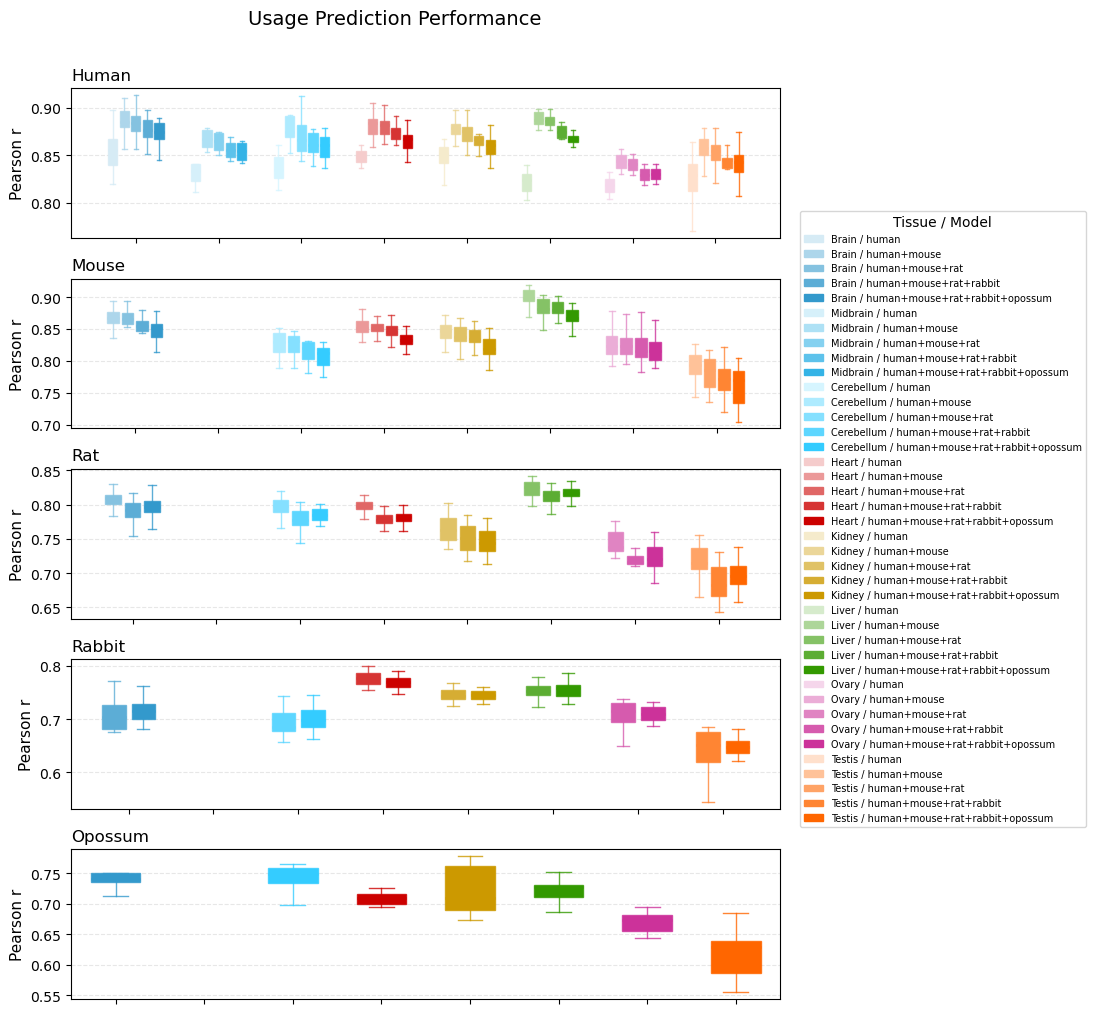

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


pred_species_list = df_usage['pred_species'].unique()
pred_species_list = [s for s in SPECIES_ORDER if s in pred_species_list]
tissues = ['Brain', 'Midbrain', 'Cerebellum', 'Heart', 'Kidney', 'Liver', 'Ovary', 'Testis']
tissues = [t for t in tissues if t in df_usage['tissue'].unique()]

n_species = len(pred_species_list)
n_tissues = len(tissues)

fig, axes = plt.subplots(n_species, 1, figsize=(8, n_species * 2), squeeze=False)
axes = axes.flatten()

for species_idx, pred_sps in enumerate(pred_species_list):
    ax = axes[species_idx]
    species_data = df_usage[(df_usage['pred_species'] == pred_sps) & (df_usage['model_species'] == pred_sps)]

    groups = [m for m in models if m in species_data['model'].unique()]
    n_groups = len(groups)
    
    box_width = 0.7 / n_groups if n_groups > 0 else 0.7

    for tissue_idx, tissue in enumerate(tissues):
        tissue_data = species_data[species_data['tissue'] == tissue]
        for group_idx, model in enumerate(groups):
            group_data = tissue_data[tissue_data['model'] == model]
            if len(group_data) > 0:
                correlations = group_data['correlation'].values
                x_pos = tissue_idx + (group_idx - n_groups / 2 + 0.5) * box_width
                color = TISSUE_MODEL_COLORS[tissue].get(model, '#888888')
                edge_color = plt.cm.colors.to_rgba(color, alpha=0.8)  # slightly darker shade for edge
                ax.boxplot([correlations], positions=[x_pos], widths=box_width * 0.8,
                    patch_artist=True, showfliers=False,
                    boxprops=dict(color=edge_color, facecolor=color),
                    medianprops=dict(color=color, linewidth=2),
                    whiskerprops=dict(color=edge_color),
                    capprops=dict(color=edge_color))
                x_jitter = np.random.normal(x_pos, box_width * 0.1, size=len(correlations))
                #ax.scatter(x_jitter, correlations, alpha=0.4, s=10, color=color, edgecolors='black', linewidths=0.3)
                ax.set_xticks(range(n_tissues))
                ax.set_xticklabels([])
                ax.set_ylabel('Pearson r', fontsize=11)
                ax.set_title(pred_sps.capitalize(), fontsize=12, loc='left')
                #ax.set_ylim(0.55, 1.05)
                ax.grid(axis='y', alpha=0.3, linestyle='--')

# Legend: one entry per (model, head_sps) pair
from matplotlib.lines import Line2D
legend_handles = []
for tissue in tissues:
    for model in models:
        color = TISSUE_MODEL_COLORS[tissue].get(model, '#888888')
        legend_handles.append(mpatches.Patch(color=color, label=f'{tissue} / {model.replace("_", "+")}'))

fig.legend(handles=legend_handles, title='Tissue / Model',
loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=7, ncol=1)
fig.suptitle('Usage Prediction Performance', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Summary

In [ ]:
# Summary: Classification AUPRC by model and species
summary_classification = df_classification.groupby(['model', 'pred_species'])['auprc'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std')
]).round(3)
print("Classification AUPRC Summary:")
display(summary_classification.round(3))

Classification AUPRC Summary:


mean  median    std
model                          pred_species                      
human                          human         0.887   0.887  0.007
                               mouse         0.945   0.946  0.004
                               opossum       0.871   0.868  0.016
                               rabbit        0.859   0.860  0.026
                               rat           0.915   0.914  0.008
human_mouse                    human         0.906   0.907  0.005
                               mouse         0.963   0.962  0.003
                               opossum       0.893   0.892  0.010
                               rabbit        0.880   0.883  0.017
                               rat           0.938   0.938  0.002
human_mouse_rat                human         0.906   0.906  0.003
                               mouse         0.958   0.957  0.003
                               opossum       0.888   0.889  0.014
                               rabbit        0.876   0.878  0.018
                               rat           0.938   0.938  0.002
human_mouse_rat_rabbit         human         0.897   0.896  0.005
                               mouse         0.962   0.961  0.002
                               opossum       0.893   0.892  0.015
                               rabbit        0.915   0.915  0.010
                               rat           0.939   0.939  0.002
human_mouse_rat_rabbit_opossum human         0.886   0.885  0.002
                               mouse         0.953   0.953  0.003
                               opossum       0.898   0.898  0.010
                               rabbit        0.921   0.924  0.007
                               rat           0.938   0.938  0.002

In [ ]:
# Exclude conditions
#blacklist = ['Brain_4', 'Brain_8', 'Cerebellum_1', 'Cerebellum_2', 'Cerebellum_3', 'Cerebellum_14', 'Cerebellum_15']
#df_usage = df_usage[~df_usage['condition_name'].isin(blacklist)]

# Summary: Usage correlations by model and tissue
summary_usage = df_usage.groupby(['tissue', 'model', 'model_species', 'pred_species'])['correlation'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('n_conditions', 'count')
]).round(2)

print("Usage Correlation Summary by Tissue and Model:")
display(summary_usage)

# Overall Summary: Usage correlations by model
overall_summary = df_usage.groupby(['model', 'model_species', 'pred_species'])['correlation'].agg([
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('n_conditions', 'count')
]).round(2)

print("\nOverall Usage Correlation Summary by Model:")
display(overall_summary)

Usage Correlation Summary by Tissue and Model:


mean  \
tissue model                          model_species pred_species         
Brain  human                          human         human         0.85   
                                                    mouse         0.82   
                                                    opossum       0.62   
                                                    rabbit        0.58   
                                                    rat           0.75   
...                                                                ...   
Testis human_mouse_rat_rabbit_opossum human         human         0.84   
                                      mouse         mouse         0.76   
                                      opossum       opossum       0.62   
                                      rabbit        rabbit        0.65   
                                      rat           rat           0.70   

                                                                  median  \
tissue model                          model_species pred_species           
Brain  human                          human         human           0.86   
                                                    mouse           0.82   
                                                    opossum         0.63   
                                                    rabbit          0.57   
                                                    rat             0.76   
...                                                                  ...   
Testis human_mouse_rat_rabbit_opossum human         human           0.84   
                                      mouse         mouse           0.77   
                                      opossum       opossum         0.63   
                                      rabbit        rabbit          0.65   
                                      rat           rat             0.70   

                                                                   std  \
tissue model                          model_species pred_species         
Brain  human                          human         human         0.02   
                                                    mouse         0.02   
                                                    opossum       0.04   
                                                    rabbit        0.02   
                                                    rat           0.02   
...                                                                ...   
Testis human_mouse_rat_rabbit_opossum human         human         0.02   
                                      mouse         mouse         0.03   
                                      opossum       opossum       0.04   
                                      rabbit        rabbit        0.05   
                                      rat           rat           0.03   

                                                                  n_conditions  
tissue model                          model_species pred_species                
Brain  human                          human         human                   15  
                                                    mouse                   14  
                                                    opossum                 13  
                                                    rabbit                  14  
                                                    rat                     14  
...                                                                        ...  
Testis human_mouse_rat_rabbit_opossum human         human                   15  
                                      mouse         mouse                   14  
                                      opossum       opossum                 11  
                                      rabbit        rabbit                  14  
                                      rat           rat                     13  

[390 rows x 4 columns]


Overall Usage Correlation Summary by Model:


mean  median   std  \
model                          model_species pred_species                       
human                          human         human         0.84    0.84  0.03   
                                             mouse         0.78    0.80  0.08   
                                             opossum       0.59    0.60  0.07   
                                             rabbit        0.57    0.58  0.06   
                                             rat           0.71    0.74  0.08   
human_mouse                    human         human         0.88    0.88  0.02   
                                             mouse         0.81    0.83  0.08   
                                             opossum       0.61    0.61  0.06   
                                             rabbit        0.59    0.60  0.06   
                                             rat           0.74    0.77  0.08   
                               mouse         human         0.85    0.86  0.05   
                                             mouse         0.84    0.85  0.04   
                                             opossum       0.63    0.63  0.04   
                                             rabbit        0.61    0.61  0.05   
                                             rat           0.76    0.77  0.04   
human_mouse_rat                human         human         0.87    0.87  0.02   
                                             mouse         0.78    0.80  0.06   
                                             opossum       0.62    0.62  0.07   
                                             rabbit        0.61    0.62  0.06   
                                             rat           0.74    0.76  0.07   
                               mouse         human         0.79    0.81  0.05   
                                             mouse         0.84    0.84  0.04   
                                             opossum       0.60    0.60  0.05   
                                             rabbit        0.56    0.56  0.06   
                                             rat           0.74    0.75  0.05   
                               rat           human         0.81    0.82  0.06   
                                             mouse         0.78    0.79  0.05   
                                             opossum       0.58    0.59  0.05   
                                             rabbit        0.57    0.57  0.06   
                                             rat           0.78    0.79  0.04   
human_mouse_rat_rabbit         human         human         0.86    0.87  0.02   
                                             mouse         0.79    0.82  0.08   
                                             opossum       0.63    0.65  0.07   
                                             rabbit        0.65    0.67  0.07   
                                             rat           0.72    0.75  0.08   
                               mouse         human         0.84    0.85  0.05   
                                             mouse         0.83    0.84  0.04   
                                             opossum       0.65    0.66  0.05   
                                             rabbit        0.70    0.71  0.05   
                                             rat           0.76    0.77  0.04   
                               rabbit        human         0.82    0.83  0.06   
                                             mouse         0.81    0.82  0.05   
                                             opossum       0.66    0.67  0.05   
                                             rabbit        0.72    0.73  0.05   
                                             rat           0.75    0.77  0.05   
                               rat           human         0.83    0.84  0.05   
                                             mouse         0.82    0.82  0.04   
                                             opossum       0.66    0.67  0.04   
         

,model,pred_species,mean,std
1,human_mouse,human,0.88,0.02
3,human_mouse_rat,human,0.87,0.02
6,human_mouse_rat_rabbit,human,0.86,0.02
10,human_mouse_rat_rabbit_opossum,human,0.86,0.02
2,human_mouse,mouse,0.84,0.04
4,human_mouse_rat,mouse,0.84,0.04
0,human,human,0.84,0.03
7,human_mouse_rat_rabbit,mouse,0.83,0.04
11,human_mouse_rat_rabbit_opossum,mouse,0.82,0.04
5,human_mouse_rat,rat,0.78,0.04


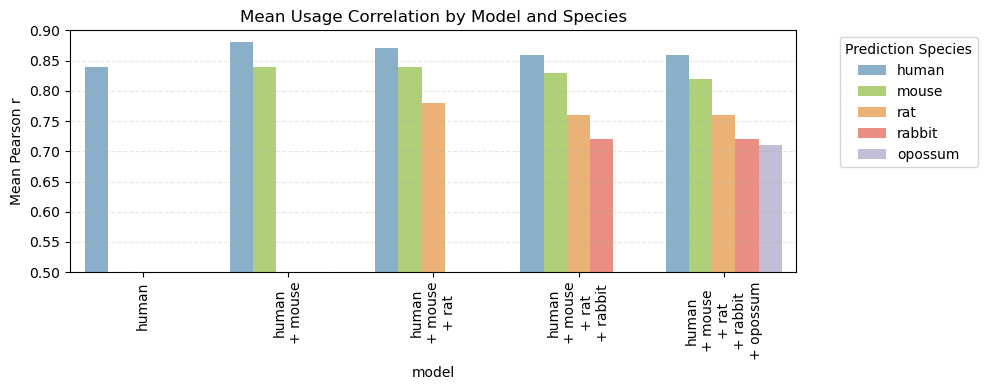

In [ ]:
# Subset where usage_head_species and pred_species match
top_summary = overall_summary.reset_index()
top_summary = top_summary[top_summary['model_species'] == top_summary['pred_species']]
# Order by pred_species, then mean correlation
top_summary = top_summary.reset_index()
top_summary = top_summary.sort_values(by=['mean'], ascending=[False])
# Subset columns to show
top_summary = top_summary[['model', 'pred_species', 'mean', 'std']]
display(top_summary)
# Models as categorical for plotting order
top_summary['model'] = pd.Categorical(top_summary['model'], categories=models, ordered=True)

import seaborn as sns

# Plot as barplot with error bars
plt.figure(figsize=(10, 4))
sns.barplot(data=top_summary, x='model', y='mean', hue='pred_species', palette=SPECIES_COLORS, capsize=0.1)
plt.xticks(rotation=45, ha='right')
plt.xticks(ticks=range(len(models)), labels=[m.replace('_', '\n+ ') for m in models], rotation=90, ha='center', va='top')
plt.ylabel('Mean Pearson r')  
plt.ylim(0.5, 0.9)
plt.title('Mean Usage Correlation by Model and Species')
plt.legend(title='Prediction Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()